In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import pandas as pd
import os
from tqdm import tqdm


In [3]:
base_dir = "/content/drive/MyDrive/New Bloodtype Detection/dataset"
records = []

for blood_type in os.listdir(base_dir):
    blood_path = os.path.join(base_dir, blood_type)
    if os.path.isdir(blood_path):
        for img_name in os.listdir(blood_path):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png','.bmp')):
                records.append({
                    "filename": img_name,
                    "blood_type": blood_type,
                    "file_path": os.path.join(blood_path, img_name)
                })

blood_df = pd.DataFrame(records)
blood_df.to_csv("blood_labels2.csv", index=False)
print("Blood labels CSV created with", len(blood_df), "rows")
blood_df.head()


Blood labels CSV created with 8001 rows


,filename,blood_type,file_path
0,augmented_cluster_7_4139.BMP,O-,/content/drive/MyDrive/New Bloodtype Detection...
1,augmented_cluster_7_4448.BMP,O-,/content/drive/MyDrive/New Bloodtype Detection...
2,augmented_cluster_7_429.BMP,O-,/content/drive/MyDrive/New Bloodtype Detection...
3,augmented_cluster_7_413.BMP,O-,/content/drive/MyDrive/New Bloodtype Detection...
4,augmented_cluster_7_4193.BMP,O-,/content/drive/MyDrive/New Bloodtype Detection...


In [4]:
import zipfile
import os


efficient_zip_path = '/content/drive/MyDrive/New Bloodtype Detection/models/efficientnet_savedmodel-20251028T153252Z-1-001.zip'
inception_zip_path = '/content/drive/MyDrive/New Bloodtype Detection/models/inceptionv3_savedmodel-20251028T153426Z-1-001.zip'


extract_dir = '/content/unzipped_models'
os.makedirs(extract_dir, exist_ok=True)

# Unzip the EfficientNet model
print(f"Unzipping {efficient_zip_path}...")
with zipfile.ZipFile(efficient_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("EfficientNet unzipped.")

# Unzip the InceptionV3 model
print(f"Unzipping {inception_zip_path}...")
with zipfile.ZipFile(inception_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
print("InceptionV3 unzipped.")

# Construct the paths to the unzipped model directories
unzipped_efficient_model_path = os.path.join(extract_dir, 'efficientnet_savedmodel')
unzipped_inception_model_path = os.path.join(extract_dir, 'inceptionv3_savedmodel')

print(f"Unzipped EfficientNet model path: {unzipped_efficient_model_path}")
print(f"Unzipped InceptionV3 model path: {unzipped_inception_model_path}")

Unzipping /content/drive/MyDrive/New Bloodtype Detection/models/efficientnet_savedmodel-20251028T153252Z-1-001.zip...
EfficientNet unzipped.
Unzipping /content/drive/MyDrive/New Bloodtype Detection/models/inceptionv3_savedmodel-20251028T153426Z-1-001.zip...
InceptionV3 unzipped.
Unzipped EfficientNet model path: /content/unzipped_models/efficientnet_savedmodel
Unzipped InceptionV3 model path: /content/unzipped_models/inceptionv3_savedmodel


In [5]:
from pathlib import Path
import tensorflow as tf
import traceback


unzipped_efficient_model_path = '/content/unzipped_models/efficientnet_savedmodel'
unzipped_inception_model_path = '/content/unzipped_models/inceptionv3_savedmodel'

#Load saved model
def load_savedmodel_safe(path: str, model_name: str):
    if not tf.io.gfile.exists(path):
        print(f"Model directory not found: {path}")
        return None

    try:
        print(f"Loading {model_name} from {path}...")
        model = tf.saved_model.load(path)
        # Get the inference function
        infer = model.signatures["serving_default"]
        print(f"{model_name} loaded successfully")
        return infer
    except Exception as e:
        print(f"Failed loading {model_name}: {e}")
        traceback.print_exc()
        return None

# load models
print("Starting model loading...")
efficient_model = load_savedmodel_safe(unzipped_efficient_model_path, "EfficientNet")
inception_model = load_savedmodel_safe(unzipped_inception_model_path, "InceptionV3")
# Check if models loaded
if efficient_model is None and inception_model is None:
    print("WARNING: No fingerprint models were loaded successfully!")

# Class labels
PATTERN_TYPES = ["class1_arc", "class2_whorl", "class3_loop"]
ENSEMBLE_WEIGHTS = {'efficientnet': 0.55, 'inception': 0.45}

Starting model loading...
Loading EfficientNet from /content/unzipped_models/efficientnet_savedmodel...
EfficientNet loaded successfully
Loading InceptionV3 from /content/unzipped_models/inceptionv3_savedmodel...
InceptionV3 loaded successfully


In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inc_preprocess
from tqdm import tqdm

# ✅ Use full dataset now
full_df = blood_df.reset_index(drop=True)

predictions = []
class_names = PATTERN_TYPES  # ["Arc","Whorl","Loop"]

def model_predict(model, img):
    img_tf = tf.constant(img)

    try:
        out = model(img_tf, training=False)
        if isinstance(out, dict):
            out = list(out.values())[0]
        return out
    except:
        pass

    try:
        out = model(img_tf)
        if isinstance(out, dict):
            out = list(out.values())[0]
        return out
    except Exception as e:
        print(f"❌ Prediction failed: {e}")
        return None

def load_and_preprocess(path):
    # EfficientNet
    img_eff = image.load_img(path, target_size=(224, 224))
    img_eff = eff_preprocess(image.img_to_array(img_eff))
    img_eff = np.expand_dims(img_eff, axis=0)

    # Inception
    img_inc = image.load_img(path, target_size=(299, 299))
    img_inc = inc_preprocess(image.img_to_array(img_inc))
    img_inc = np.expand_dims(img_inc, axis=0)

    return img_eff, img_inc

for _, row in tqdm(full_df.iterrows(), total=len(full_df)):
    img_path = row["file_path"]

    eff_img, inc_img = load_and_preprocess(img_path)

    eff_out = model_predict(efficient_model, eff_img)
    inc_out = model_predict(inception_model, inc_img)

    if eff_out is None and inc_out is None:
        print(f"⚠️ Skipping {img_path}")
        continue

    eff_out = np.squeeze(eff_out.numpy() if hasattr(eff_out, "numpy") else eff_out)
    inc_out = np.squeeze(inc_out.numpy() if hasattr(inc_out, "numpy") else inc_out)

    # ✅ Custom ensemble rule
    if eff_out[0] > 0.90:   # EfficientNet very confident it's ARC
        final_out = inc_out  # trust Inception instead
    else:
        final_out = 0.6 * eff_out + 0.4 * inc_out

    pred_idx = int(np.argmax(final_out))
    pred_pattern = class_names[pred_idx]

    predictions.append({
        "filename": row["filename"],
        "file_path": img_path,
        "blood_type": row["blood_type"],
        "fingerprint_type": pred_pattern,
        "P_Arc": float(final_out[0]),
        "P_Whorl": float(final_out[1]),
        "P_Loop": float(final_out[2])
    })

df_pred = pd.DataFrame(predictions)
df_pred.to_csv("blood_fingerprint_FULL.csv", index=False)

print("\n✅ DONE — Saved to blood_fingerprint_FULL.csv")
print(df_pred["fingerprint_type"].value_counts())
df_pred.head()


 15%|█▍        | 1184/8001 [02:56<16:57,  6.70it/s]  


KeyboardInterrupt: 

In [10]:
import pandas as pd

# Load the combined dataset CSV
df = pd.read_csv("blood_fingerprint_FULL (1).csv")
print("Combined dataset loaded successfully.\n")

# Display the first few rows and the value counts for fingerprint type
display(df.head())
print("\nValue counts for predicted fingerprint types:")
print(df["fingerprint_type"].value_counts())

Combined dataset loaded successfully.



,filename,file_path,blood_type,fingerprint_type,P_Arc,P_Whorl,P_Loop
0,augmented_cluster_7_4139.BMP,/content/drive/MyDrive/New Bloodtype Detection...,O-,class3_loop,0.182517,0.385048,0.432435
1,augmented_cluster_7_4448.BMP,/content/drive/MyDrive/New Bloodtype Detection...,O-,class3_loop,0.202444,0.368944,0.428612
2,augmented_cluster_7_429.BMP,/content/drive/MyDrive/New Bloodtype Detection...,O-,class3_loop,0.231777,0.348496,0.419727
3,augmented_cluster_7_413.BMP,/content/drive/MyDrive/New Bloodtype Detection...,O-,class3_loop,0.378918,0.172949,0.448133
4,augmented_cluster_7_4193.BMP,/content/drive/MyDrive/New Bloodtype Detection...,O-,class3_loop,0.153210,0.381885,0.464905



Value counts for predicted fingerprint types:
fingerprint_type
class2_whorl    3419
class3_loop     3120
class1_arc      1462
Name: count, dtype: int64


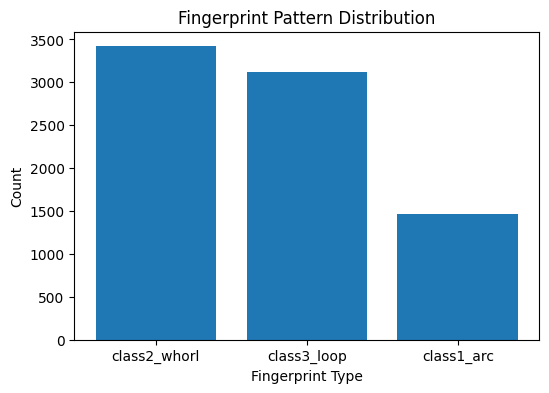

In [11]:
import matplotlib.pyplot as plt

counts = df["fingerprint_type"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title("Fingerprint Pattern Distribution")
plt.xlabel("Fingerprint Type")
plt.ylabel("Count")
plt.show()


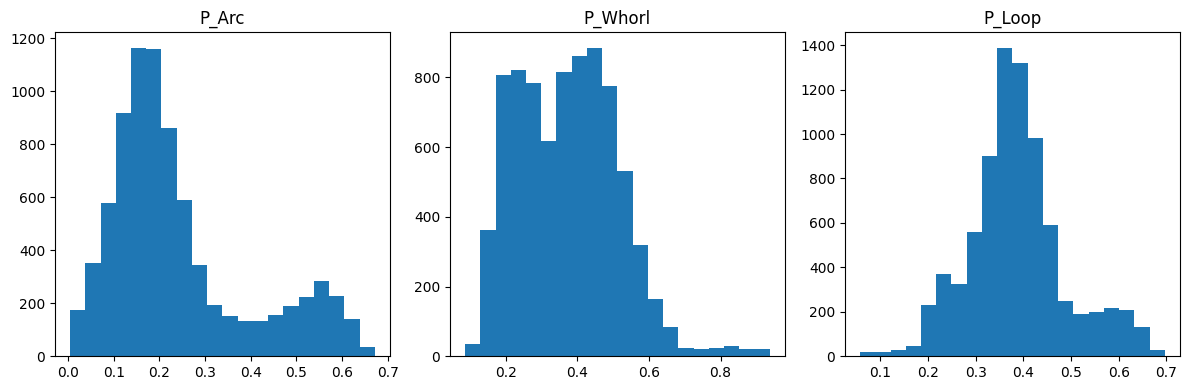

In [12]:
plt.figure(figsize=(12,4))
for i, col in enumerate(["P_Arc", "P_Whorl", "P_Loop"]):
    plt.subplot(1,3,i+1)
    plt.hist(df[col], bins=20)
    plt.title(col)
plt.tight_layout()
plt.show()


fingerprint_type  class1_arc  class2_whorl  class3_loop
blood_type                                             
A+                 11.200000     49.400000    39.400000
A-                 20.879121     37.862138    41.258741
AB+                16.200000     53.600000    30.200000
AB-                26.100000     29.200000    44.700000
B+                 13.200000     51.600000    35.200000
B-                 15.500000     42.900000    41.600000
O+                 18.300000     44.500000    37.200000
O-                 24.800000     32.800000    42.400000


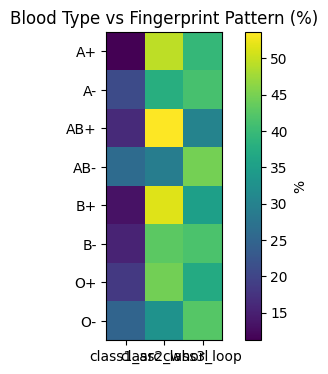

In [13]:
ct = pd.crosstab(df["blood_type"], df["fingerprint_type"], normalize="index") * 100
print(ct)

plt.figure(figsize=(6,4))
plt.imshow(ct, cmap="viridis")
plt.colorbar(label="%")
plt.xticks(range(len(ct.columns)), ct.columns)
plt.yticks(range(len(ct.index)), ct.index)
plt.title("Blood Type vs Fingerprint Pattern (%)")
plt.show()


In [14]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.graphics.mosaicplot import mosaic

df['fingerprint_type'] = df['fingerprint_type'].astype('category')
df['blood_type'] = df['blood_type'].astype('category')

# contingency table
ct = pd.crosstab(df['fingerprint_type'], df['blood_type'])
print("\nContingency Table:")
print(ct)



Contingency Table:
blood_type         A+   A-  AB+  AB-   B+   B-   O+   O-
fingerprint_type                                        
class1_arc        112  209  162  261  132  155  183  248
class2_whorl      494  379  536  292  516  429  445  328
class3_loop       394  413  302  447  352  416  372  424


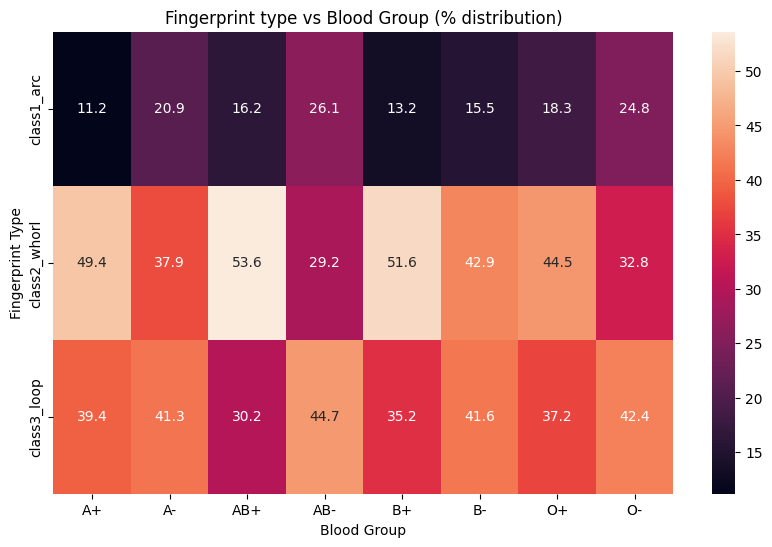

In [15]:
# Percentage distribution of fingerprint type and blood group
plt.figure(figsize=(10,6))
sns.heatmap(ct.div(ct.sum(axis=0), axis=1)*100, annot=True, fmt=".1f")
plt.title("Fingerprint type vs Blood Group (% distribution)")
plt.xlabel("Blood Group")
plt.ylabel("Fingerprint Type")
plt.show()



<Figure size 1000x500 with 0 Axes>

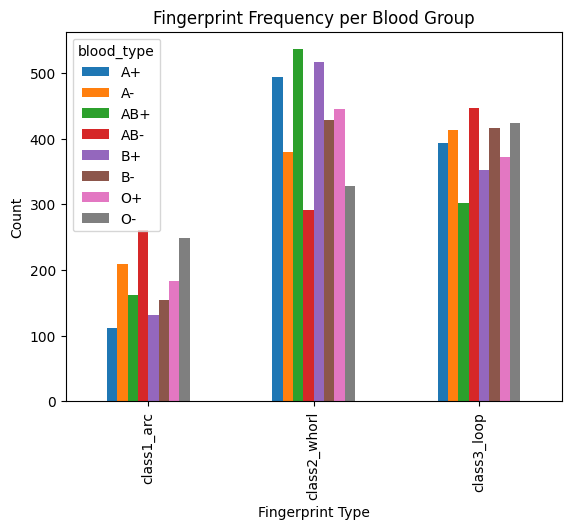

In [16]:
# Bar plot for frequency of fingerprints based on blood groups
plt.figure(figsize=(10,5))
ct.plot(kind='bar', stacked=False)
plt.title("Fingerprint Frequency per Blood Group")
plt.ylabel("Count")
plt.xlabel("Fingerprint Type")
plt.show()

<Figure size 1000x800 with 0 Axes>

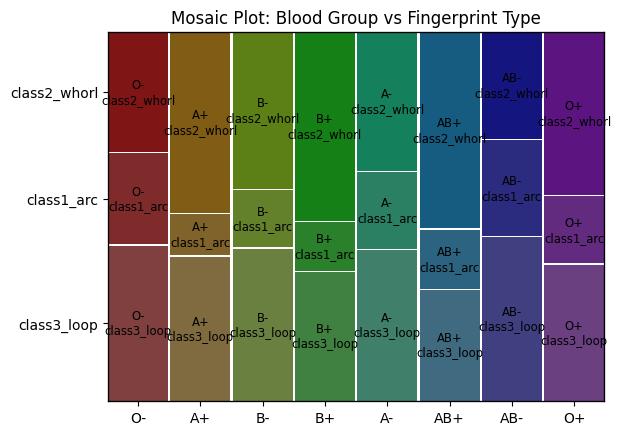

In [17]:
# mosaic plot
plt.figure(figsize=(10,8))
mosaic(df, ['blood_type', 'fingerprint_type'])
plt.title("Mosaic Plot: Blood Group vs Fingerprint Type")
plt.show()

In [18]:
# chi square test
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"\nChi-square = {chi2:.4f}, p-value = {p:.4f}, DOF = {dof}")
print("\nExpected frequencies:\n", pd.DataFrame(expected, index=ct.index, columns=ct.columns))



Chi-square = 276.0356, p-value = 0.0000, DOF = 14

Expected frequencies:
 blood_type                A+          A-         AB+         AB-          B+  \
fingerprint_type                                                               
class1_arc        182.727159  182.909886  182.727159  182.727159  182.727159   
class2_whorl      427.321585  427.748906  427.321585  427.321585  427.321585   
class3_loop       389.951256  390.341207  389.951256  389.951256  389.951256   

blood_type                B-          O+          O-  
fingerprint_type                                      
class1_arc        182.727159  182.727159  182.727159  
class2_whorl      427.321585  427.321585  427.321585  
class3_loop       389.951256  389.951256  389.951256  


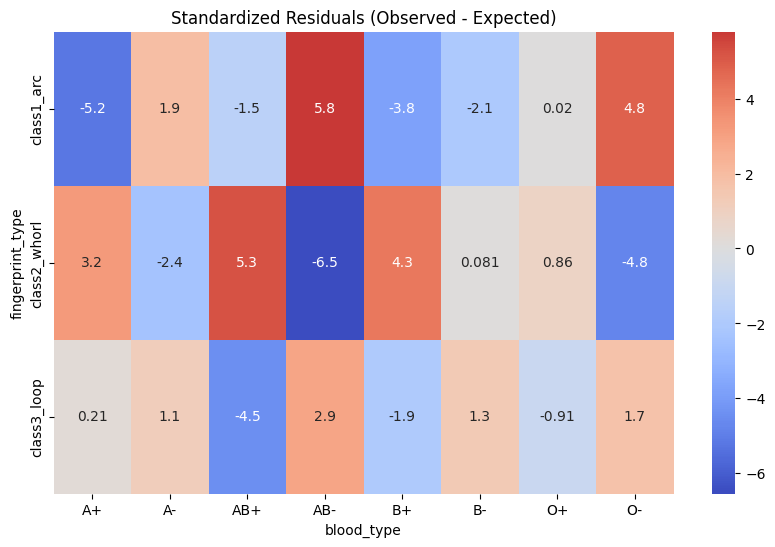

In [19]:
# residual plot for observed results-expected results
residuals = (ct - expected) / np.sqrt(expected)
plt.figure(figsize=(10,6))
sns.heatmap(residuals, annot=True, cmap="coolwarm", center=0)
plt.title("Standardized Residuals (Observed - Expected)")
plt.show()

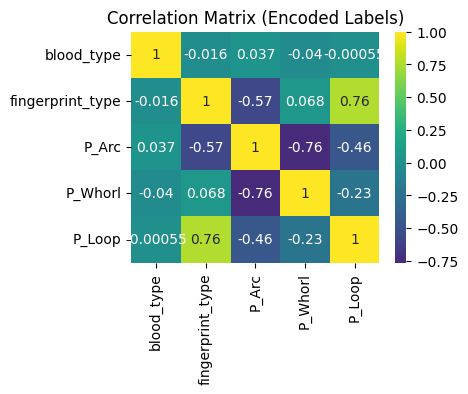

In [20]:
#Correlation between fingerprints and blood types
df_enc = df.copy()
df_enc['fingerprint_type'] = df_enc['fingerprint_type'].cat.codes
df_enc['blood_type'] = df_enc['blood_type'].cat.codes

# Drop non-numeric columns before correlation
df_enc_numeric = df_enc.drop(['filename', 'file_path'], axis=1)

plt.figure(figsize=(4,3))
sns.heatmap(df_enc_numeric.corr(), annot=True, cmap="viridis", center=0)
plt.title("Correlation Matrix (Encoded Labels)")
plt.show()

In [21]:
# Log Odds ratio
print("\nLog Odds Ratios:")
for fp in ct.index:
    for bg in ct.columns:
        observed = ct.loc[fp, bg]
        # Calculate log odds ratio against the total sum excluding the observed cell
        total = ct.sum().sum()
        other = total - observed
        odds = observed / other if other != 0 else np.nan
        log_odds = np.log(odds) if odds > 0 else np.nan
        print(f"{fp} vs {bg}: {log_odds:.4f}")


Log Odds Ratios:
class1_arc vs A+: -4.2547
class1_arc vs A-: -3.6185
class1_arc vs AB+: -3.8793
class1_arc vs AB-: -3.3896
class1_arc vs B+: -4.0879
class1_arc vs B-: -3.9243
class1_arc vs O+: -3.7547
class1_arc vs O-: -3.4424
class2_whorl vs A+: -2.7211
class2_whorl vs A-: -3.0013
class2_whorl vs AB+: -2.6338
class2_whorl vs AB-: -3.2734
class2_whorl vs B+: -2.6745
class2_whorl vs B-: -2.8708
class2_whorl vs O+: -2.8320
class2_whorl vs O-: -3.1524
class3_loop vs A+: -2.9605
class3_loop vs A-: -2.9109
class3_loop vs AB+: -3.2384
class3_loop vs AB-: -2.8273
class3_loop vs B+: -3.0787
class3_loop vs B-: -2.9032
class3_loop vs O+: -3.0208
class3_loop vs O-: -2.8831


In [26]:
from sklearn.calibration import calibration_curve
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# True labels (NOW CORRECT)
# -------------------------------
label_map = {
    "class1_arc": 0,
    "class2_whorl": 1,
    "class3_loop": 2
}

y_true = df_pred['true_label'].map(label_map).values

# -------------------------------
# Predicted probabilities
# -------------------------------
probs = df_pred[['P_Arc', 'P_Whorl', 'P_Loop']].values

confidences = np.max(probs, axis=1)
pred_labels = np.argmax(probs, axis=1)

correct = (pred_labels == y_true).astype(int)

# -------------------------------
# Calibration curve
# -------------------------------
prob_true, prob_pred = calibration_curve(correct, confidences, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect Calibration')

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability Diagram")
plt.legend()
plt.show()

# -------------------------------
# ECE
# -------------------------------
bins = np.linspace(0, 1, 11)
binids = np.digitize(confidences, bins) - 1

ece = 0
for i in range(len(bins)-1):
    mask = binids == i
    if np.sum(mask) > 0:
        acc = np.mean(correct[mask])
        conf = np.mean(confidences[mask])
        ece += np.abs(acc - conf) * np.sum(mask) / len(confidences)

print(f"\n📏 ECE: {ece:.4f}")

NameError: name 'df_pred' is not defined

In [23]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from itertools import combinations
from statsmodels.stats.multitest import multipletests

# -------------------------------
# 1. Sample Size Reporting
# -------------------------------
n_samples = len(df)
print(f"\n📊 Total Sample Size Used: {n_samples}")

print("\nBlood Group Distribution:")
print(df['blood_type'].value_counts())

print("\nFingerprint Type Distribution:")
print(df['fingerprint_type'].value_counts())

# -------------------------------
# 2. Chi-square + Cramer's V
# -------------------------------
ct = pd.crosstab(df['fingerprint_type'], df['blood_type'])
chi2, p, dof, expected = chi2_contingency(ct)

n = ct.sum().sum()
phi2 = chi2 / n
r, k = ct.shape
cramers_v = np.sqrt(phi2 / (min(k-1, r-1)))

print(f"\nChi-square: {chi2:.2f}, p-value: {p:.5f}")
print(f"Cramer's V: {cramers_v:.3f}")

# -------------------------------
# 3. Bootstrapped CI for Cramer's V
# -------------------------------
def cramers_v_stat(table):
    chi2, _, _, _ = chi2_contingency(table)
    n = table.sum().sum()
    phi2 = chi2 / n
    r, k = table.shape
    return np.sqrt(phi2 / (min(k-1, r-1)))

boot_vals = []
B = 1000

for _ in range(B):
    sample_df = df.sample(frac=1, replace=True)
    sample_ct = pd.crosstab(sample_df['fingerprint_type'], sample_df['blood_type'])

    # align shape
    sample_ct = sample_ct.reindex(index=ct.index, columns=ct.columns, fill_value=0)

    boot_vals.append(cramers_v_stat(sample_ct))

ci_lower = np.percentile(boot_vals, 2.5)
ci_upper = np.percentile(boot_vals, 97.5)

print(f"\n📌 Bootstrapped 95% CI for Cramer's V: [{ci_lower:.3f}, {ci_upper:.3f}]")

# -------------------------------
# 4. Post-hoc Pairwise Tests (Blood Groups)
# -------------------------------
print("\n🔍 Post-hoc Pairwise Chi-square Tests:")

blood_groups = df['blood_type'].unique()
pair_results = []

for bg1, bg2 in combinations(blood_groups, 2):
    sub_df = df[df['blood_type'].isin([bg1, bg2])]
    sub_ct = pd.crosstab(sub_df['fingerprint_type'], sub_df['blood_type'])

    chi2_pair, p_pair, _, _ = chi2_contingency(sub_ct)

    pair_results.append((bg1, bg2, p_pair))

# Multiple testing correction (Bonferroni)
pairs_df = pd.DataFrame(pair_results, columns=["Group1", "Group2", "p_value"])
pairs_df["p_adj"] = multipletests(pairs_df["p_value"], method='bonferroni')[1]

print(pairs_df.sort_values("p_adj"))

# -------------------------------
# 5. Power Analysis (Approximate)
# -------------------------------
# Using Cohen's w (approx = Cramer's V for contingency tables)
effect_size = cramers_v
alpha = 0.05

# Rough heuristic for required sample size
required_n = ( (1.96 + 0.84)**2 ) / (effect_size**2)

print(f"\n⚡ Approx. Sample Size Needed for 80% Power: {int(required_n)}")


📊 Total Sample Size Used: 8001

Blood Group Distribution:
blood_type
A-     1001
A+     1000
AB+    1000
AB-    1000
B+     1000
B-     1000
O+     1000
O-     1000
Name: count, dtype: int64

Fingerprint Type Distribution:
fingerprint_type
class2_whorl    3419
class3_loop     3120
class1_arc      1462
Name: count, dtype: int64

Chi-square: 276.04, p-value: 0.00000
Cramer's V: 0.131

📌 Bootstrapped 95% CI for Cramer's V: [0.120, 0.148]

🔍 Post-hoc Pairwise Chi-square Tests:
   Group1 Group2       p_value         p_adj
25    AB+    AB-  1.817787e-27  5.089803e-26
20     B+    AB-  7.376263e-26  2.065354e-24
11     A+    AB-  1.194580e-25  3.344825e-24
4      O-    AB+  5.722833e-20  1.602393e-18
0      O-     A+  2.113929e-19  5.919002e-18
2      O-     B+  5.843084e-19  1.636064e-17
16     B-    AB-  1.739303e-12  4.870049e-11
27    AB-     O+  4.324638e-12  1.210899e-10
22     A-    AB+  1.304876e-11  3.653652e-10
9      A+     A-  1.772176e-10  4.962093e-09
18     B+     A-  4.116676

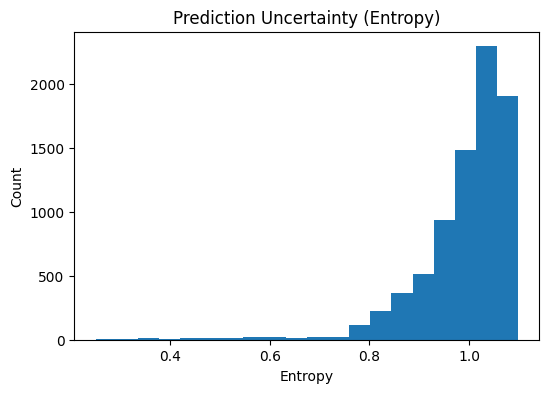

In [28]:
from scipy.stats import entropy

probs = df[['P_Arc','P_Whorl','P_Loop']].values
ent = entropy(probs.T)

plt.figure(figsize=(6,4))
plt.hist(ent, bins=20)
plt.title("Prediction Uncertainty (Entropy)")
plt.xlabel("Entropy")
plt.ylabel("Count")
plt.show()

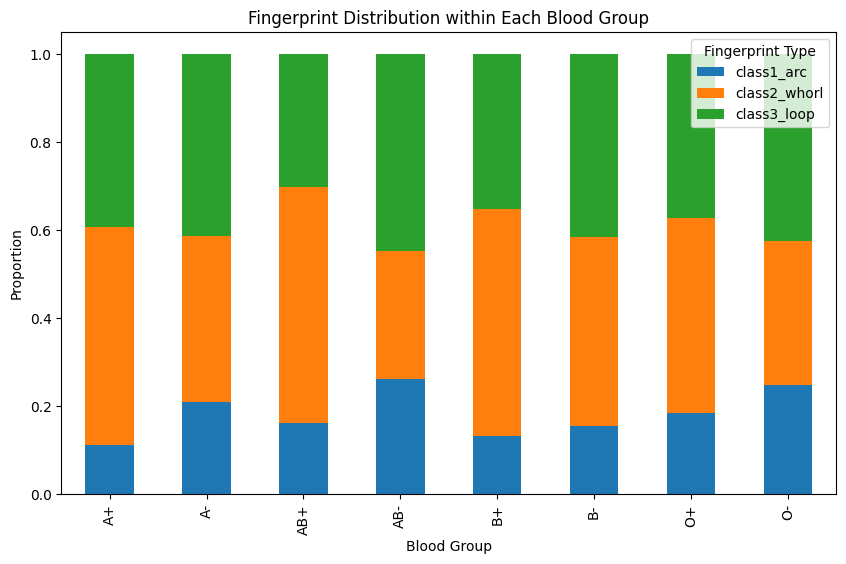

In [29]:
prop_ct = pd.crosstab(df['blood_type'], df['fingerprint_type'], normalize='index')

prop_ct.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Fingerprint Distribution within Each Blood Group")
plt.ylabel("Proportion")
plt.xlabel("Blood Group")
plt.legend(title="Fingerprint Type")
plt.show()